# ESTELA Analysis for Unstructured Grid

This notebook demonstrates how to use the modified ESTELA code for unstructured grid data.

In [1]:
# Import required libraries
import sys
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(" ")

# Import ESTELA functions
from estela_unstructured import calc_unstructured, plot_unstructured

## 1. Setup Parameters

In [7]:
# Data directory (adjust to your data location)
data_dir = " " 

# Time range
start_date = "198901"  # YYYYMM format
end_date = "198912"    # YYYYMM format

# Target point 
# Hasaki    35.906, 140.758
# Omotehama 34.60, 137.41
# Kanazawa  37.03, 136.28
lat0 = 35.906   # 纬度
lon0 = 140.758  # 经度

# Directional spread (constant value in degrees)
si = 20 

# Time groupers
groupers = ["ALL", "time.season"]  # optional: ["ALL", "time.season", "time.month"]

## 2. Calculate ESTELA

In [8]:
# Calculate ESTELA dataset
estelas = calc_unstructured(
    data_dir=data_dir,
    start_date=start_date,
    end_date=end_date,
    lat0=lat0,
    lon0=lon0,
    groupers=groupers
)

print("ESTELA calculation completed!")
print(f"Dataset dimensions: {estelas.dims}")
print(f"Available times: {list(estelas.time.values)}")

2025-12-24 14:12:10,173 - INFO - ================================================================================
2025-12-24 14:12:10,173 - INFO - ESTELA calculation for lat0=35.906, lon0=140.758
2025-12-24 14:12:10,174 - INFO - Period: 198901 to 198912
2025-12-24 14:12:10,175 - INFO - ================================================================================
2025-12-24 14:12:11,295 - INFO - No fixed SI provided. SPR files found - will use variable directional spread from files
2025-12-24 14:12:11,296 - INFO - Reading spatial coordinates (once only)...
2025-12-24 14:12:11,337 - INFO - Total nodes: 334968
2025-12-24 14:12:11,337 - INFO - Reading triangulation...
2025-12-24 14:12:11,371 - INFO - Calculating geographic mask...
2025-12-24 14:12:11,405 - INFO - Valid nodes: 60407 (18.0%)
2025-12-24 14:12:11,405 - INFO - Filtered 274561 nodes blocked by land
2025-12-24 14:12:11,405 - INFO - Pre-calculating coefficients...
2025-12-24 14:12:11,408 - INFO - Variable directional spread mod

ESTELA calculation completed!
Dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 5, 'node': 334968, 'site': 1, 'vertex': 3, 'triangle': 604923})
Available times: [np.str_('ALL'), np.str_('DJF'), np.str_('JJA'), np.str_('MAM'), np.str_('SON')]


## 3. Explore the Results

In [9]:
# Display dataset structure
print(estelas)

<xarray.Dataset> Size: 37MB
Dimensions:        (time: 5, node: 334968, site: 1, vertex: 3, triangle: 604923)
Coordinates:
  * time           (time) <U3 60B 'ALL' 'DJF' 'JJA' 'MAM' 'SON'
    longitude      (node) float32 1MB 25.39 22.37 24.35 ... 51.55 218.6 119.8
    latitude       (node) float32 1MB 64.96 65.83 65.79 ... -9.281 69.77 -6.414
Dimensions without coordinates: node, site, vertex, triangle
Data variables:
    F              (time, node) float64 13MB nan nan nan nan ... nan nan nan nan
    traveltime     (time, node) float64 13MB nan nan nan nan ... nan nan nan nan
    lat0           (site) float64 8B 35.91
    lon0           (site) float64 8B 140.8
    triangulation  (vertex, triangle) int32 7MB 274982 141771 ... 270317 6839
Attributes:
    start_time:         198901
    end_time:           198912
    nvalid_nodes:       60407
    ntotal_nodes:       334968
    has_triangulation:  1


In [10]:
# Check energy flux statistics
print("\nEnergy Flux Statistics:")
print(f"Mean F: {estelas.F.mean().values:.2f} kW/m/°")
print(f"Max F: {estelas.F.max().values:.2f} kW/m/°")
print(f"Min F: {estelas.F.min().values:.2f} kW/m/°")

print("\nTravel Time Statistics:")
print(f"Mean travel time: {estelas.traveltime.mean().values:.2f} days")
print(f"Max travel time: {estelas.traveltime.max().values:.2f} days")


Energy Flux Statistics:
Mean F: 16.10 kW/m/°
Max F: 125.42 kW/m/°
Min F: 0.00 kW/m/°

Travel Time Statistics:
Mean travel time: 10.49 days
Max travel time: 31.50 days


## 4. Plot ESTELA Maps

2025-12-24 14:14:43,318 - INFO - Plotting estelas for time=['ALL']
2025-12-24 14:14:43,918 - INFO - Saving ./estela_output/estela_unstructured_ALL_base.png
2025-12-24 14:14:44,374 - INFO - Plotting estelas for time=['DJF', 'MAM', 'JJA', 'SON']
2025-12-24 14:14:46,563 - INFO - Saving ./estela_output/estela_unstructured_time.season_base.png


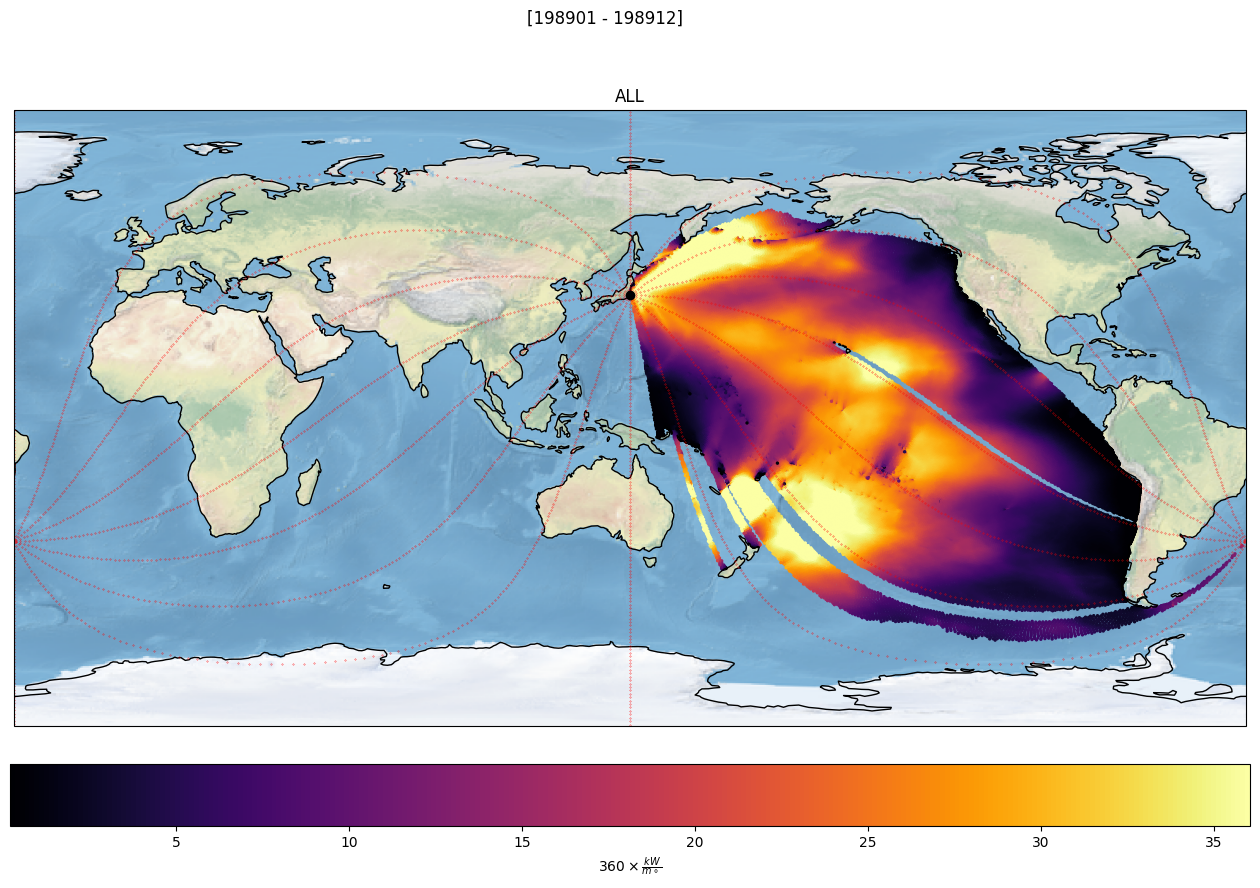

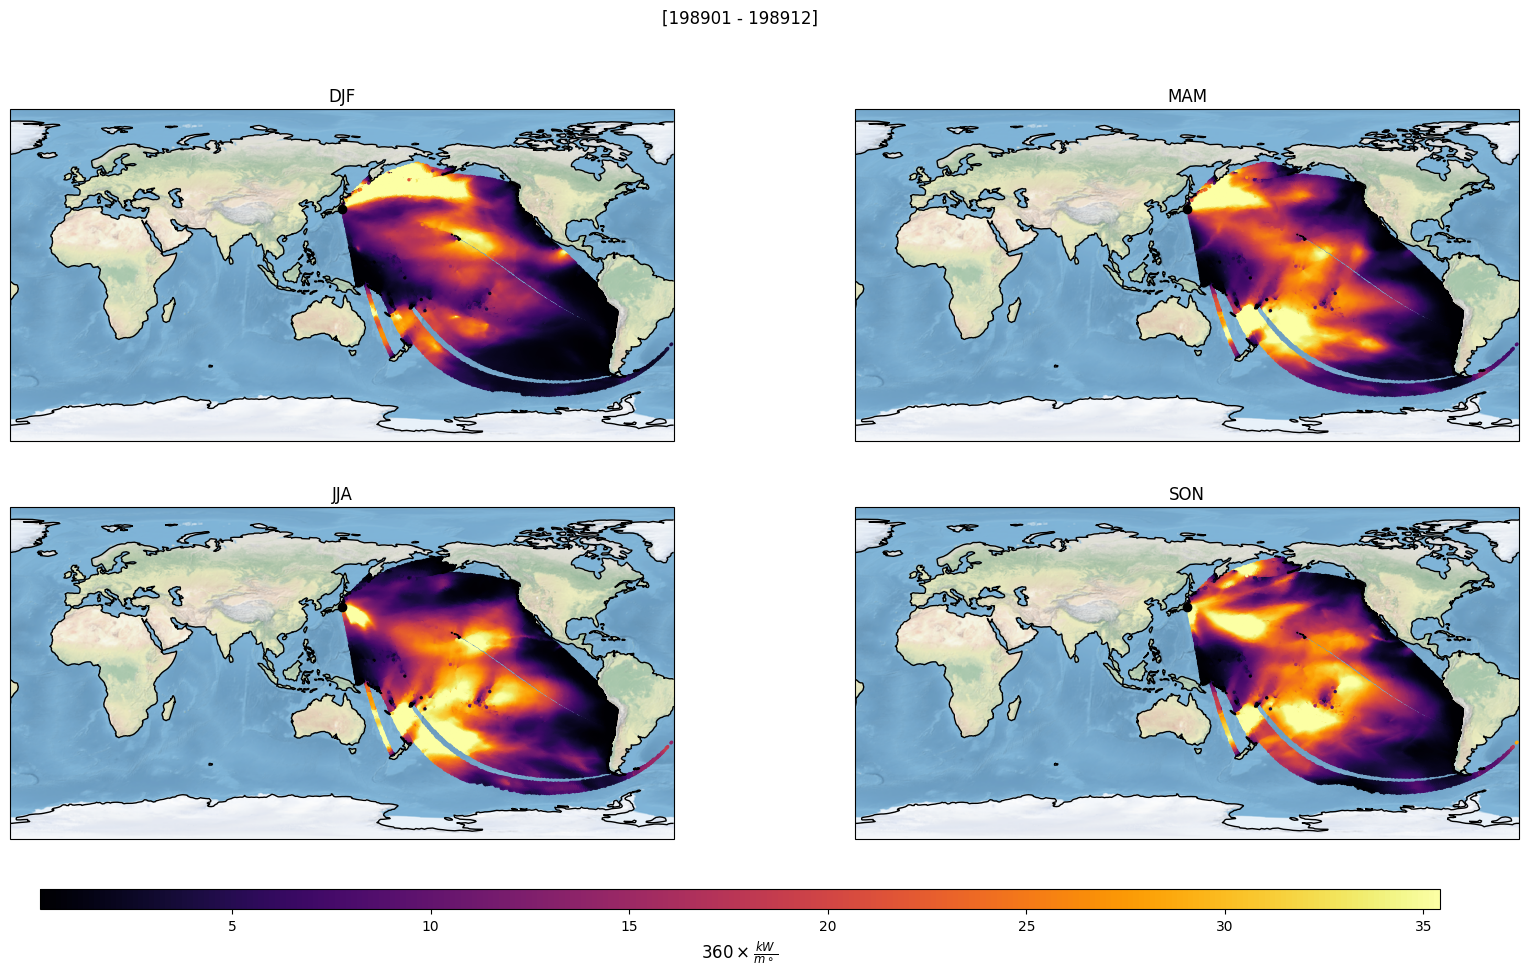

In [11]:
# Create output directory
output_dir = "./estela_output"
Path(output_dir).mkdir(exist_ok=True)

# Plot ESTELA maps
figs = plot_unstructured(
    estelas,
    groupers=groupers,
    figsize=(20, 10),
    scatter_size=2,  # 调整点的大小
    outdir=output_dir
)

plt.show()

2025-12-19 09:57:01,292 - INFO - Interpolating to polar grid for G/L calculation...
2025-12-19 09:57:01,293 - INFO -   Processing time: ALL
2025-12-19 09:57:01,307 - INFO -     Valid triangles: 123953 / 604923



Plotting Gain/Loss maps...


2025-12-19 09:57:06,073 - INFO - Polar grid interpolation completed
2025-12-19 09:57:06,075 - INFO - Plotting estelas for time=['ALL']
2025-12-19 09:57:06,945 - INFO - Saving ./estela_output/estela_unstructured_ALL_gainloss.png
2025-12-19 09:57:07,115 - INFO - Interpolating to polar grid for G/L calculation...
2025-12-19 09:57:07,116 - INFO -   Processing time: DJF
2025-12-19 09:57:07,119 - INFO -     Valid triangles: 124907 / 604923
2025-12-19 09:57:11,802 - INFO -   Processing time: MAM
2025-12-19 09:57:11,805 - INFO -     Valid triangles: 124253 / 604923
2025-12-19 09:57:16,548 - INFO -   Processing time: JJA
2025-12-19 09:57:16,552 - INFO -     Valid triangles: 125745 / 604923
2025-12-19 09:57:21,305 - INFO -   Processing time: SON
2025-12-19 09:57:21,308 - INFO -     Valid triangles: 125516 / 604923
2025-12-19 09:57:26,040 - INFO - Polar grid interpolation completed
2025-12-19 09:57:26,043 - INFO - Plotting estelas for time=['DJF', 'MAM', 'JJA', 'SON']
2025-12-19 09:57:29,315 - IN

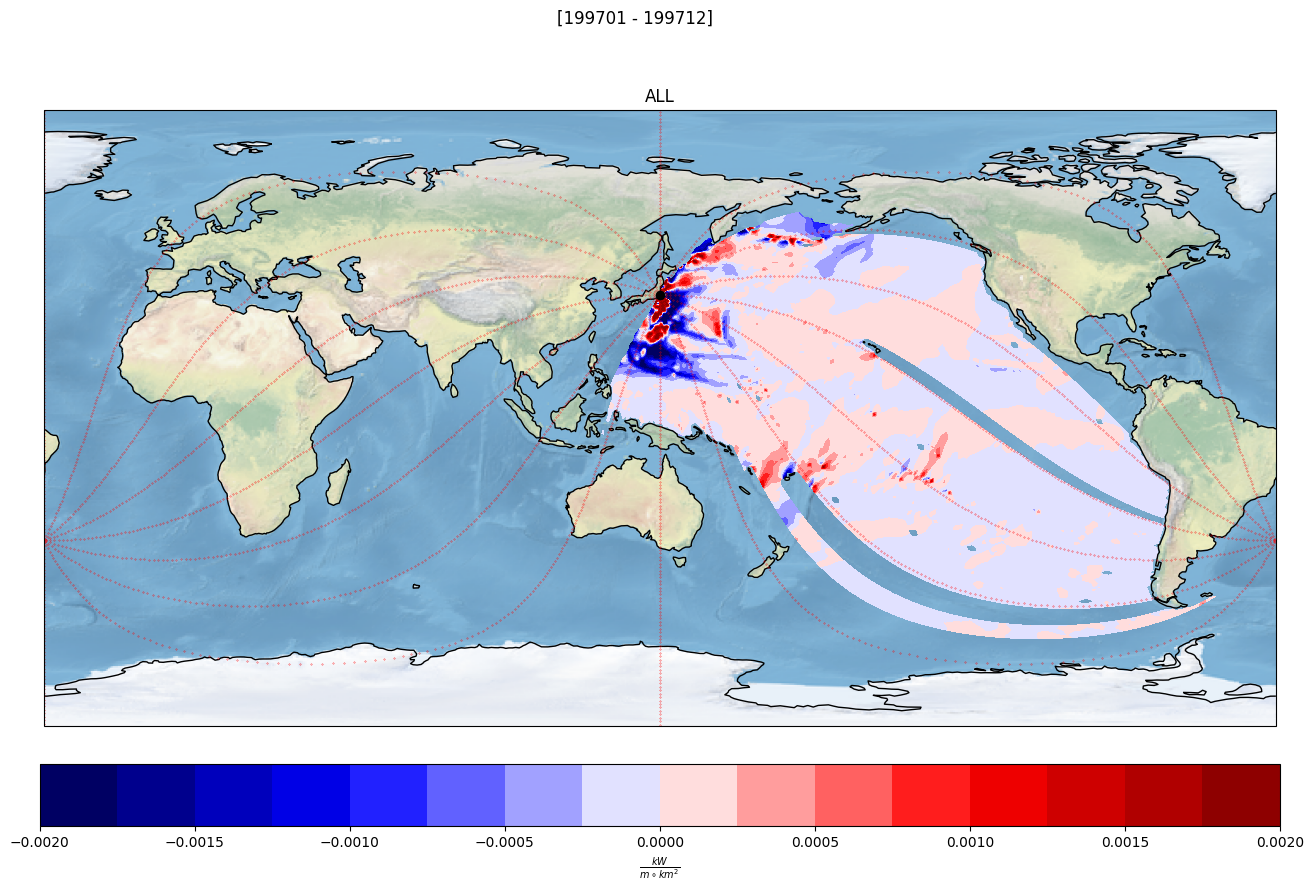

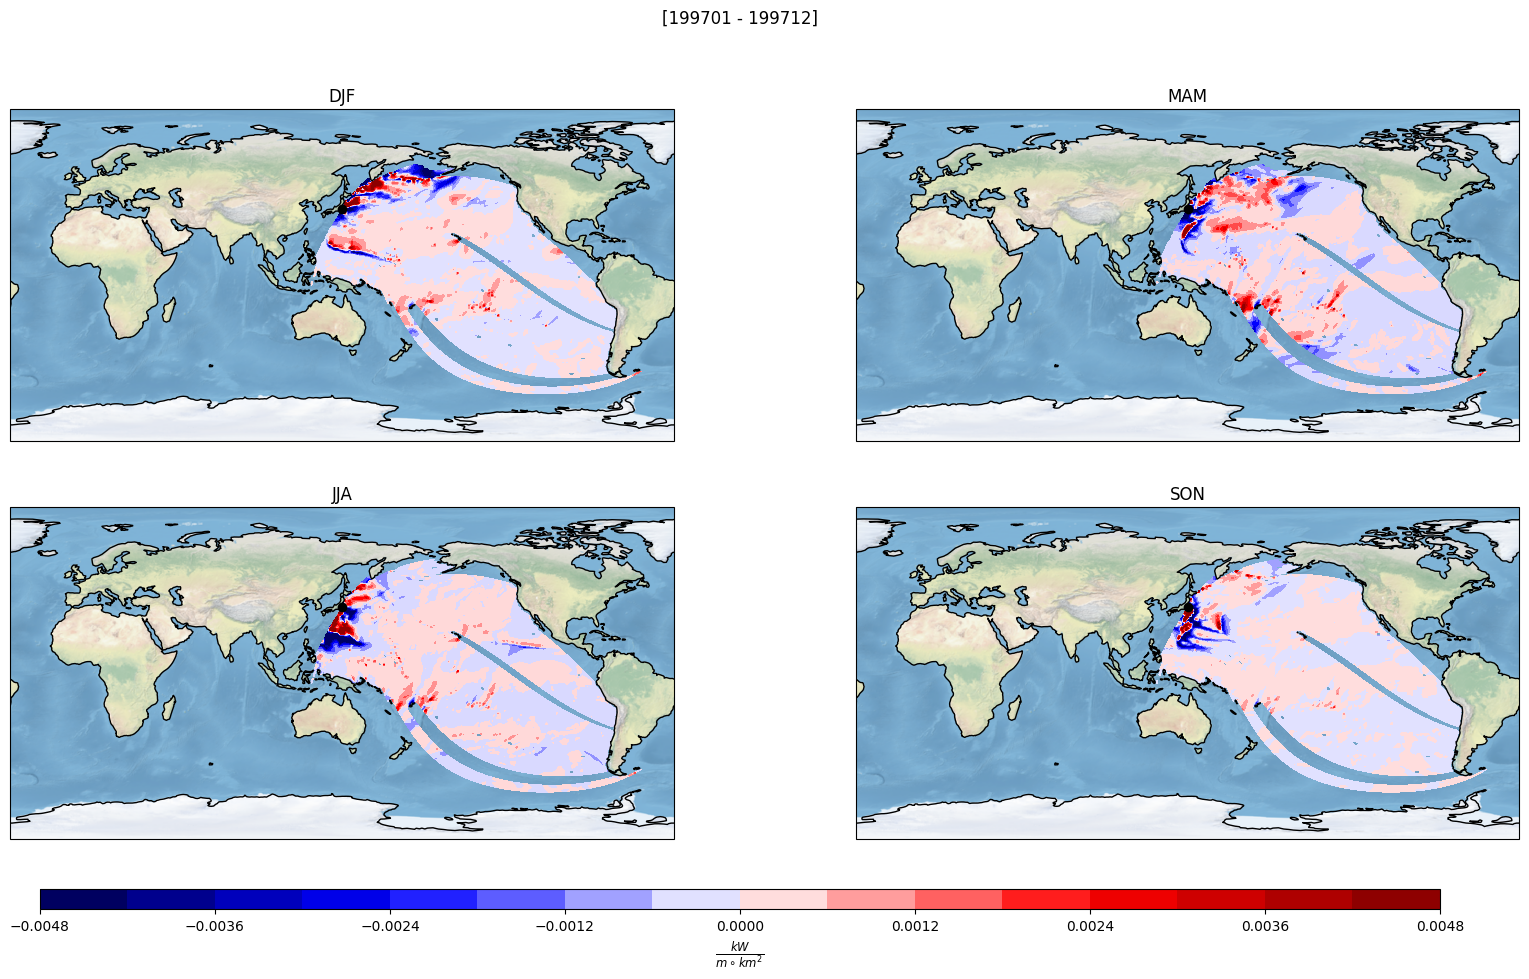

In [20]:
print("\nPlotting Gain/Loss maps...")
figs_gl = plot_unstructured(
    estelas,
    groupers=groupers,
    gainloss=True,  
    figsize=(20, 10),
    outdir=output_dir
)
plt.show()